In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
theta12= 33.68
theta13= 8.56
theta23= 43.3
dcp= 212.0
dm21= 7.49e-5
dm31= 2.513e-3

c12 = np.cos(np.radians(theta12))
s12 = np.sin(np.radians(theta12))
c13 = np.cos(np.radians(theta13))
s13 = np.sin(np.radians(theta13))
c23 = np.cos(np.radians(theta23))
s23 = np.sin(np.radians(theta23))

U=[[c12*c13, s12*c13, s13*np.exp(-1j*dcp)],
   [-s12*c23-c12*s23*s13*np.exp(1j*dcp), c12*c23-s12*s23*s13*np.exp(1j*dcp), s23*c13],
   [s12*s23-c12*c23*s13*np.exp(1j*dcp), -c12*s23-s12*c23*s13*np.exp(1j*dcp), c23*c13]]

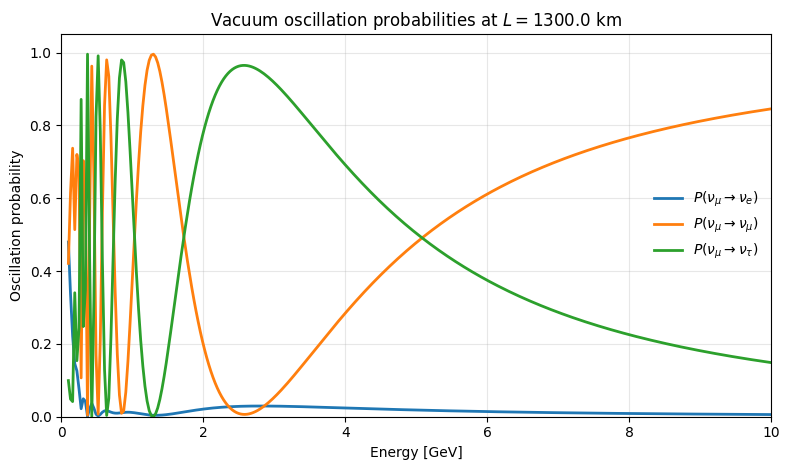

In [3]:
def P_alpha_to_beta(E_GeV, L_km, U, alpha, beta, antineutrino=False):
    """Vacuum oscillation probability P(alpha -> beta) using a supplied PMNS matrix U."""
    E = np.asarray(E_GeV, dtype=float)
    if np.any(E <= 0):
        raise ValueError("Energies must be positive.")

    flavor_to_index = {"e": 0, "mu": 1, "tau": 2}
    i = flavor_to_index[alpha]
    j = flavor_to_index[beta]

    U = np.asarray(U, dtype=complex)
    if antineutrino:
        U = U.conj()

    mass2 = np.array([0.0, dm21, dm31], dtype=float)
    phase = np.exp(-2j * 1.267 * mass2[:, None] * L_km / E[None, :])

    # A_{a,b} = sum_k U_{a,k} U^*_{b,k} e^{-i m_k^2 L / 2E}
    # In the standard convention this is equivalent to the usual probability formula.
    amplitude = np.einsum("bi,ai,ie->bae", U, U.conj(), phase)
    P = np.abs(amplitude) ** 2
    return P[i, j]


def P_matrix_vs_energy(E_GeV, L_km, U, antineutrino=False):
    """Return P[alpha, beta, E] for all flavor pairs using the supplied PMNS matrix."""
    flavor_order = ["e", "mu", "tau"]
    P = np.empty((3, 3, len(E_GeV)), dtype=float)
    for i, alpha in enumerate(flavor_order):
        for j, beta in enumerate(flavor_order):
            P[i, j, :] = P_alpha_to_beta(E_GeV, L_km, U, alpha, beta, antineutrino=antineutrino)
    return P


L_km = 1300.0
E_GeV = np.linspace(0.1, 60.0, 2000)
P_all = P_matrix_vs_energy(E_GeV, L_km, U)

transitions = {
    ("mu", "e"): "tab:blue",
    ("mu", "mu"): "tab:orange",
    ("mu", "tau"): "tab:green",
}

flavor_subscript = {
    "e": "e",
    "mu": r"\mu",
    "tau": r"\tau",
}

fig, ax = plt.subplots(figsize=(8, 4.8))
for (alpha, beta), color in transitions.items():
    i = ["e", "mu", "tau"].index(alpha)
    j = ["e", "mu", "tau"].index(beta)
    ax.plot(E_GeV, P_all[i, j], lw=2, color=color,
            label = rf"$P(\nu_{{{flavor_subscript[alpha]}}} \rightarrow \nu_{{{flavor_subscript[beta]}}})$")

ax.set_xlabel("Energy [GeV]")
ax.set_ylabel("Oscillation probability")
ax.set_title(rf"Vacuum oscillation probabilities at $L={L_km}$ km")
# ax.set_xlim(E_GeV.min(), E_GeV.max())
ax.set_xlim(0,10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
